# Lista 01 - Aprendizagem de Máquina

### Aluno: Jônatas Fernandes
### Matrícula: 603243

## **Montando o Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


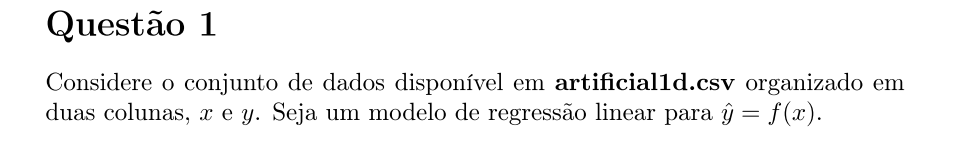

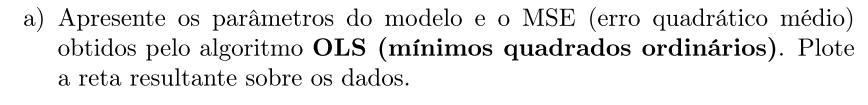

In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# caminho do dataset no drive
# OBS: Mudar para o daminho da máquina local
caminho_artificial1d_dataset = '/content/artificial1d.txt'

In [8]:
# carregando dados
dataset = np.genfromtxt(caminho_artificial1d_dataset, delimiter=',')

x = dataset[:, 0]
y = dataset[:, 1]

In [9]:
# reshape para vetor coluna
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

In [10]:
# adicionando bias
X = np.hstack((np.ones_like(x), x))

In [11]:
# MSE
def mse(y, y_hat):
    return np.mean((y - y_hat)**2)

OLS:
w0 = 0.06761792463834031
w1 = 1.5748651690368314
MSE = 0.21340090132936987


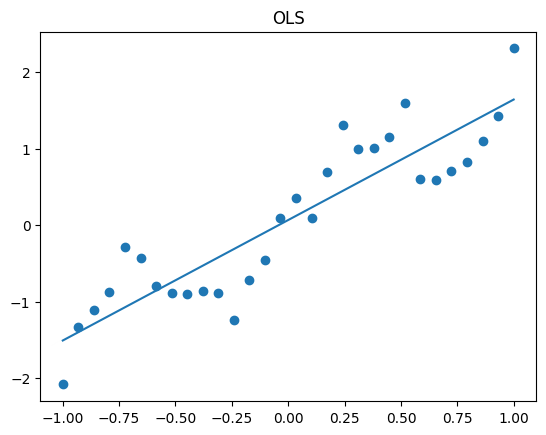

In [12]:
# OLS
w_ols = np.linalg.inv(X.T @ X) @ X.T @ y

y_hat_ols = X @ w_ols
erro_ols = mse(y, y_hat_ols)

print("OLS:")
print("w0 =", w_ols[0][0])
print("w1 =", w_ols[1][0])
print("MSE =", erro_ols)

# gráfico
plt.scatter(x, y)
plt.plot(x, y_hat_ols)
plt.title("OLS")
plt.show()

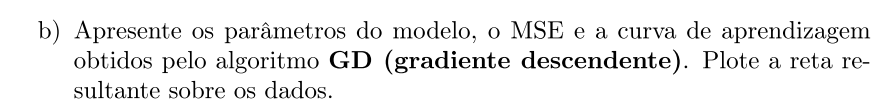


GD:
w0 = 0.06761792462456626
w1 = 1.5738958780073073
MSE = 0.21340128944989642


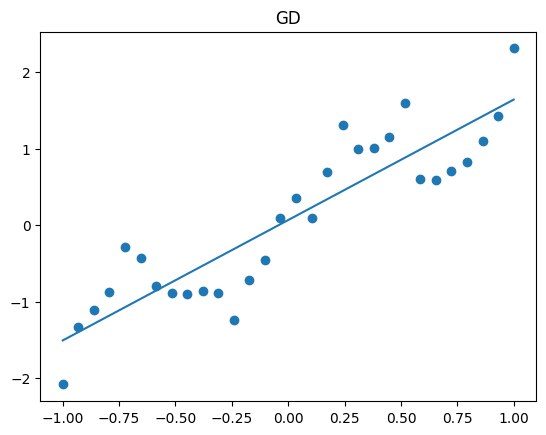

In [13]:
# parâmetros
alpha = 0.1
epochs = 100

w_gd = np.zeros((2,1))
N = len(x)

erros_gd = []

for epoch in range(epochs):
    y_hat = X @ w_gd
    error = y_hat - y

    grad = (2/N) * (X.T @ error)
    w_gd = w_gd - alpha * grad

    erros_gd.append(mse(y, y_hat))

print("\nGD:")
print("w0 =", w_gd[0][0])
print("w1 =", w_gd[1][0])
print("MSE =", erros_gd[-1])

# gráfico reta
plt.scatter(x, y)
plt.plot(x, X @ w_gd)
plt.title("GD")
plt.show()

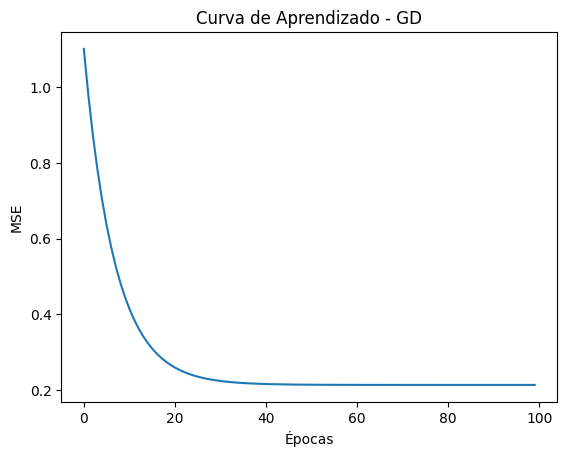

In [14]:
# curva de aprendizado
plt.plot(erros_gd)
plt.title("Curva de Aprendizado - GD")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.show()

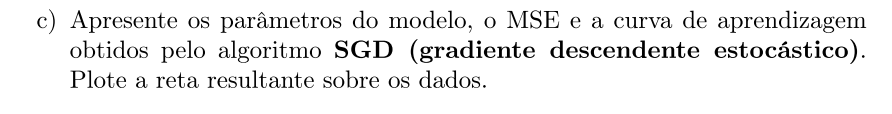


SGD:
w0 = 0.06652907456541267
w1 = 1.5760579633229441
MSE = 0.2134025938836728


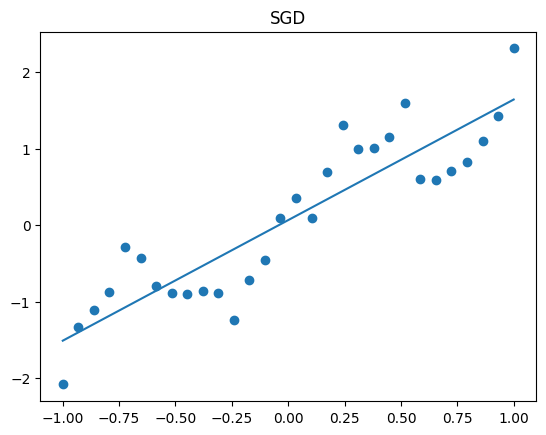

In [15]:
alpha = 0.01
epochs = 100

w_sgd = np.zeros((2,1))
erros_sgd = []

for epoch in range(epochs):
    for i in range(N):
        xi = X[i].reshape(1, -1)
        yi = y[i]

        y_hat = xi @ w_sgd
        error = y_hat - yi

        grad = 2 * xi.T * error
        w_sgd = w_sgd - alpha * grad

    # erro por época
    erros_sgd.append(mse(y, X @ w_sgd))

print("\nSGD:")
print("w0 =", w_sgd[0][0])
print("w1 =", w_sgd[1][0])
print("MSE =", erros_sgd[-1])

# gráfico reta
plt.scatter(x, y)
plt.plot(x, X @ w_sgd)
plt.title("SGD")
plt.show()

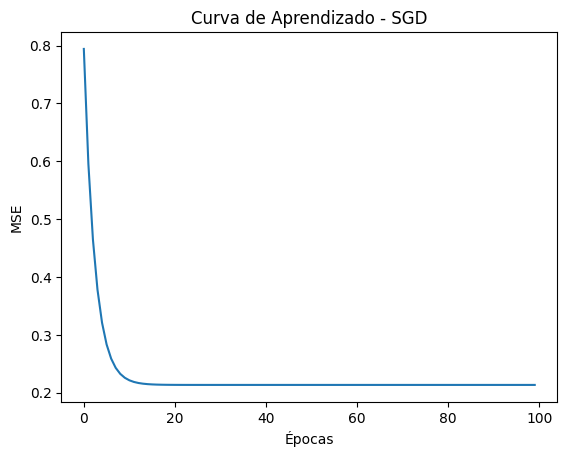

In [16]:
# curva de aprendizado
plt.plot(erros_sgd)
plt.title("Curva de Aprendizado - SGD")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.show()

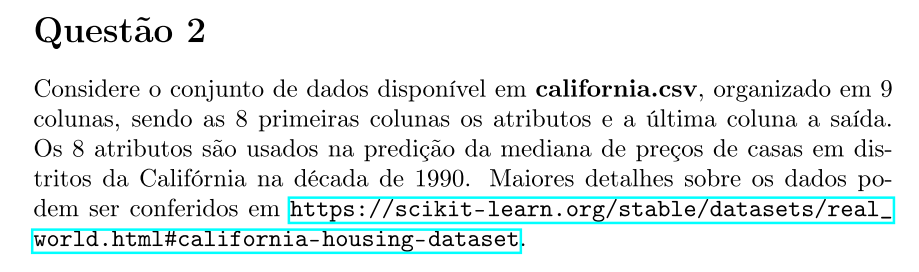

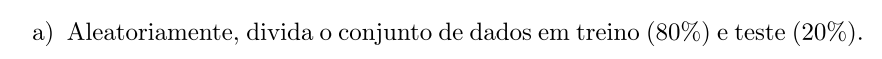

In [17]:
caminho_california_dataset = '/content/california.txt'

In [18]:
# carregando dados
data = np.genfromtxt(caminho_california_dataset, delimiter=',')

X = data[:, :-1]
y = data[:, -1].reshape(-1, 1)

In [19]:
# normalização dos dados
# MinMax para X
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min)

# StandardScaler para y
y_mean = y.mean()
y_std = y.std()
y_norm = (y - y_mean) / y_std

In [20]:
# Divisão dos dados 80/20 aleatoriamente
np.random.seed(42)

indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train = X_norm[train_idx]
X_test = X_norm[test_idx]

y_train = y_norm[train_idx]
y_test = y_norm[test_idx]

In [21]:
print("Tamanho treino:", len(X_train))
print("Tamanho teste:", len(X_test))

Tamanho treino: 800
Tamanho teste: 200


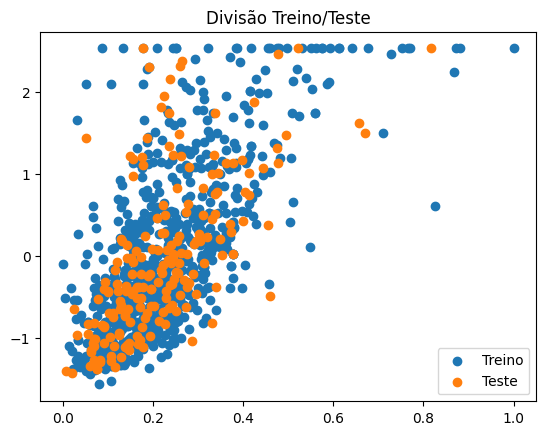

In [22]:
plt.scatter(X_train[:, 0], y_train, label='Treino')
plt.scatter(X_test[:, 0], y_test, label='Teste')
plt.legend()
plt.title('Divisão Treino/Teste')
plt.show()

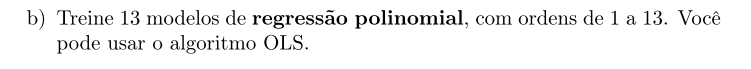

In [25]:
def criar_features_polinomiais(X, grau):
    X_poly = X.copy()

    for g in range(2, grau + 1):
        X_poly = np.hstack((X_poly, X**g))

    # adiciona bias
    X_poly = np.hstack((np.ones((X_poly.shape[0], 1)), X_poly))

    return X_poly


def treinar_ols(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y


modelos = []

for grau in range(1, 14):
    X_train_poly = criar_features_polinomiais(X_train, grau)

    theta = treinar_ols(X_train_poly, y_train)

    modelos.append((grau, theta))

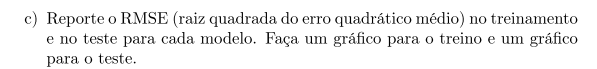

In [26]:
# RMSE
def rmse(y_real, y_pred):
    return np.sqrt(np.mean((y_real - y_pred)**2))

In [28]:
# Treino dos modelos
rmse_train_list = []
rmse_test_list = []

for grau, theta in modelos:

    # treino
    X_train_poly = criar_features_polinomiais(X_train, grau)
    y_pred_train = X_train_poly @ theta

    # teste
    X_test_poly = criar_features_polinomiais(X_test, grau)
    y_pred_test = X_test_poly @ theta

    # DESNORMALIZAR y
    y_train_real = y_train * y_std + y_mean
    y_test_real = y_test * y_std + y_mean

    y_pred_train_real = y_pred_train * y_std + y_mean
    y_pred_test_real = y_pred_test * y_std + y_mean

    # RMSE
    rmse_train_list.append(rmse(y_train_real, y_pred_train_real))
    rmse_test_list.append(rmse(y_test_real, y_pred_test_real))

graus = list(range(1, 14))

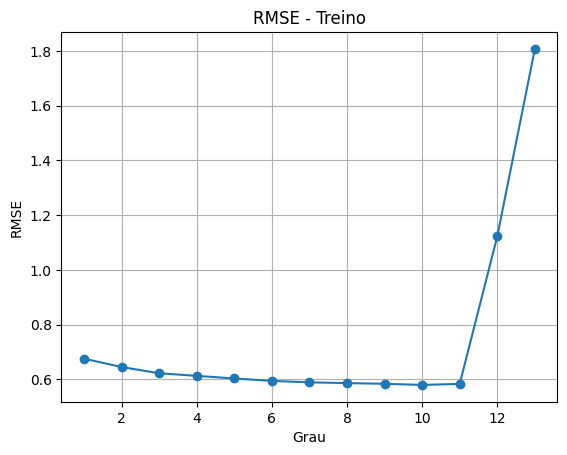

In [29]:
plt.figure()
plt.plot(graus, rmse_train_list, marker='o')
plt.title('RMSE - Treino')
plt.xlabel('Grau')
plt.ylabel('RMSE')
plt.grid()
plt.show()

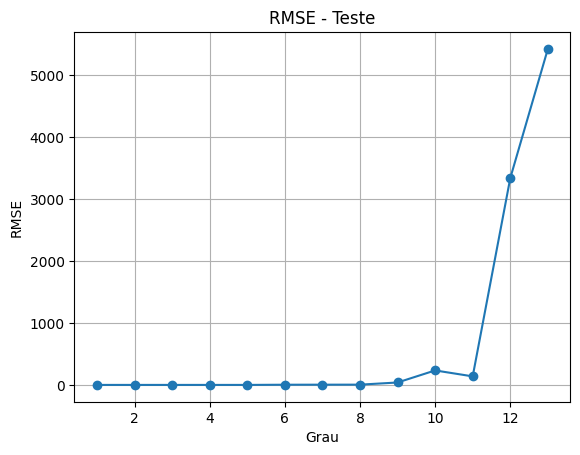

In [30]:
plt.figure()
plt.plot(graus, rmse_test_list, marker='o')
plt.title('RMSE - Teste')
plt.xlabel('Grau')
plt.ylabel('RMSE')
plt.grid()
plt.show()

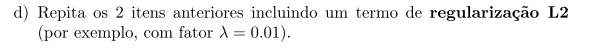

In [31]:
# Regularização L2
def treinar_ridge(X, y, lambda_):
    n = X.shape[1]
    I = np.eye(n)

    return np.linalg.inv(X.T @ X + lambda_ * I) @ X.T @ y

In [32]:
# Treino regularizado
lambda_ = 0.01

rmse_train_l2 = []
rmse_test_l2 = []

for grau in range(1, 14):

    X_train_poly = criar_features_polinomiais(X_train, grau)
    X_test_poly = criar_features_polinomiais(X_test, grau)

    theta = treinar_ridge(X_train_poly, y_train, lambda_)

    # previsões
    y_pred_train = X_train_poly @ theta
    y_pred_test = X_test_poly @ theta

    # DESNORMALIZAR y
    y_train_real = y_train * y_std + y_mean
    y_test_real = y_test * y_std + y_mean

    y_pred_train_real = y_pred_train * y_std + y_mean
    y_pred_test_real = y_pred_test * y_std + y_mean

    # RMSE
    rmse_train_l2.append(rmse(y_train_real, y_pred_train_real))
    rmse_test_l2.append(rmse(y_test_real, y_pred_test_real))

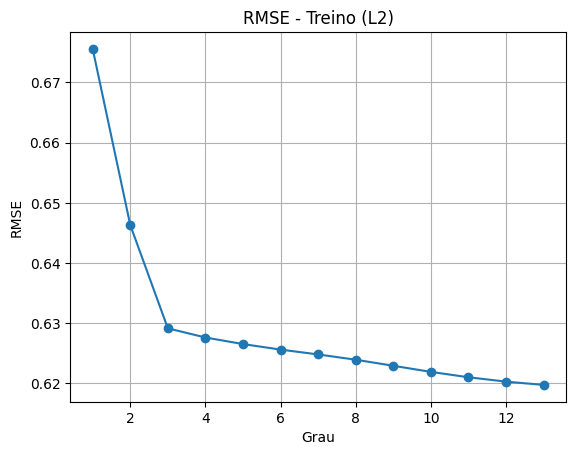

In [33]:
plt.figure()
plt.plot(graus, rmse_train_l2, marker='o')
plt.title('RMSE - Treino (L2)')
plt.xlabel('Grau')
plt.ylabel('RMSE')
plt.grid()
plt.show()

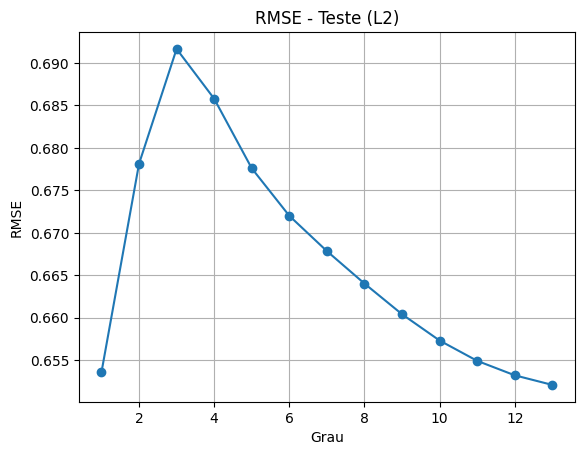

In [34]:
plt.figure()
plt.plot(graus, rmse_test_l2, marker='o')
plt.title('RMSE - Teste (L2)')
plt.xlabel('Grau')
plt.ylabel('RMSE')
plt.grid()
plt.show()